In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

# Load Dataset
df = pd.read_csv("../dataset/netflix_titles.csv")

# Display first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
# Dataset Information
print("Shape of Dataset:", df.shape)
print("\nColumns:\n", df.columns)

df.info()

Shape of Dataset: (8807, 12)

Columns:
 Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [3]:
# Check Missing Values
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

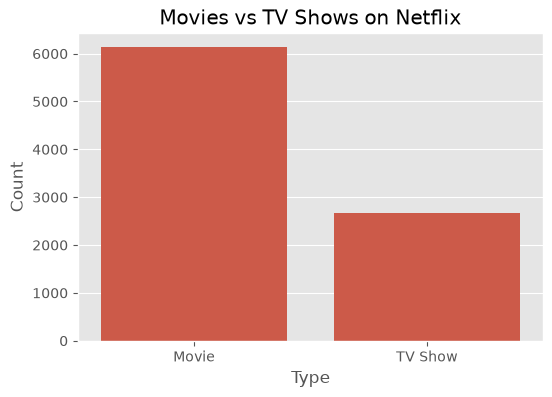

In [4]:
# Movies vs TV Shows
plt.figure(figsize=(6,4))

sns.countplot(x='type', data=df)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

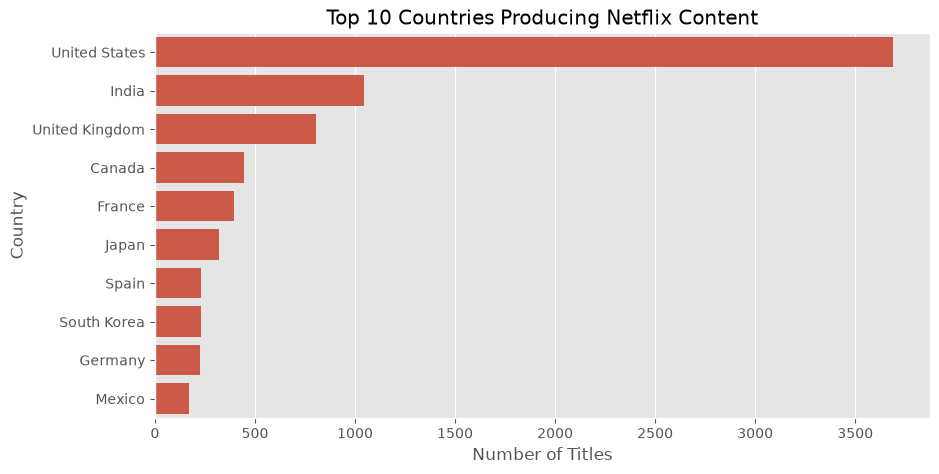

In [5]:
# Top 10 Countries
top_countries = (
    df['country']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

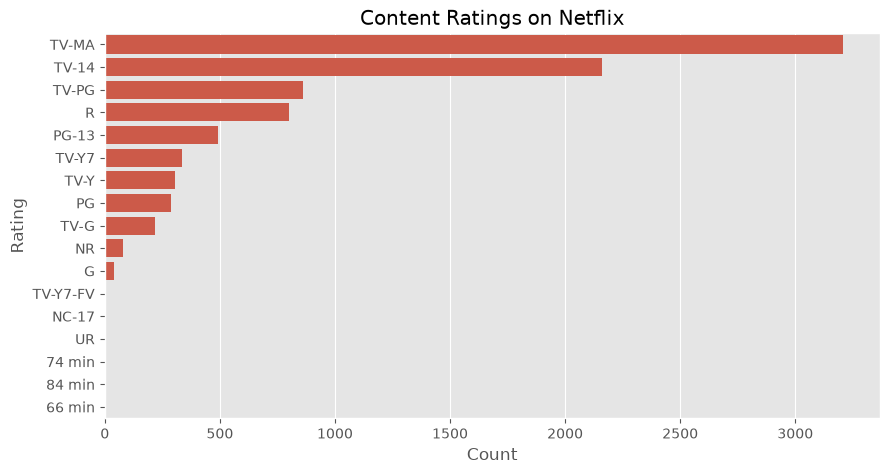

In [6]:
# Content Ratings
plt.figure(figsize=(10,5))

sns.countplot(
    y='rating',
    data=df,
    order=df['rating'].value_counts().index
)

plt.title("Content Ratings on Netflix")
plt.xlabel("Count")
plt.ylabel("Rating")

plt.show()

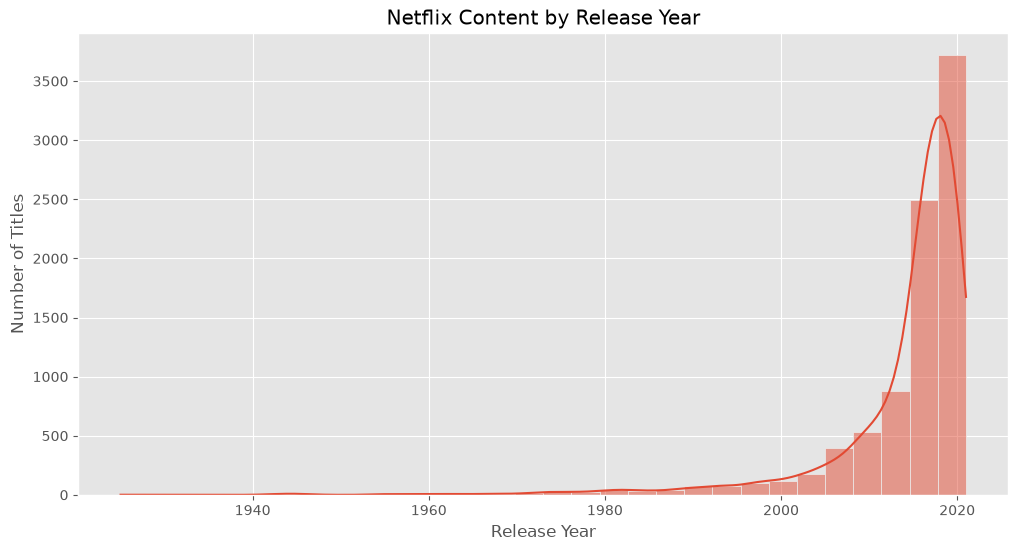

In [7]:
# Netflix Content by Release Year
plt.figure(figsize=(12,6))

sns.histplot(df['release_year'], bins=30, kde=True)

plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

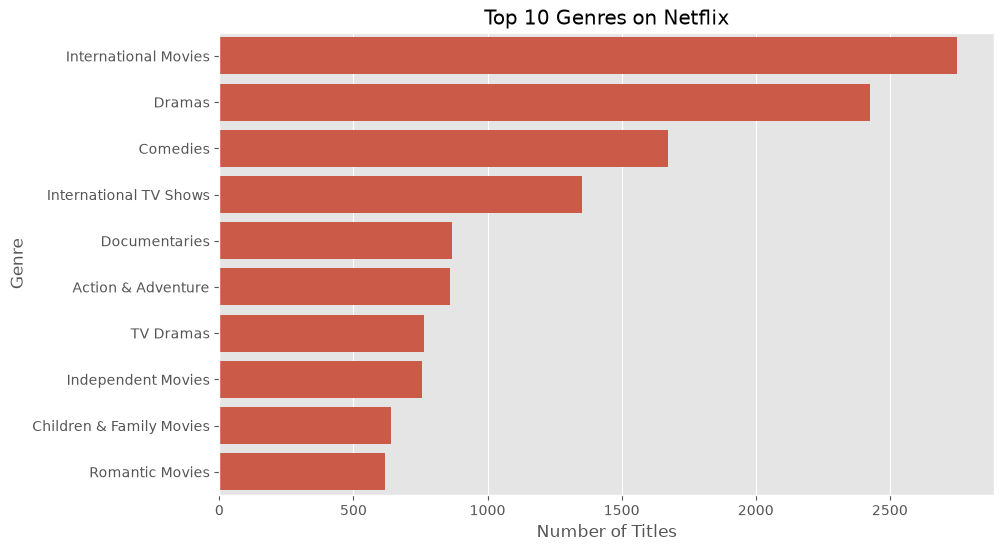

In [8]:
# Top 10 Genres
top_genres = (
    df['listed_in']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

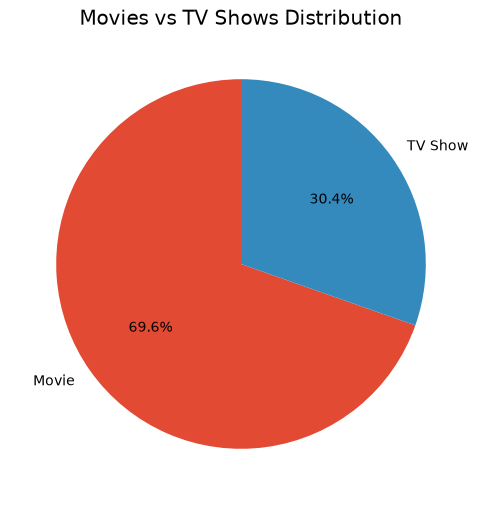

In [9]:
# Movies vs TV Shows Pie Chart
type_counts = df['type'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Movies vs TV Shows Distribution")

plt.show()

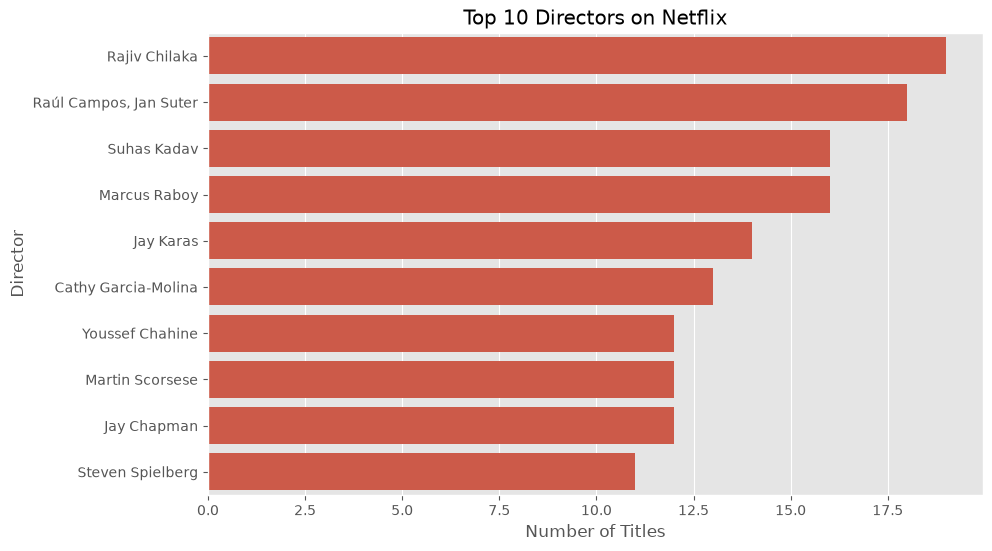

In [10]:
# Top 10 Directors
top_directors = (
    df['director']
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(x=top_directors.values, y=top_directors.index)

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()

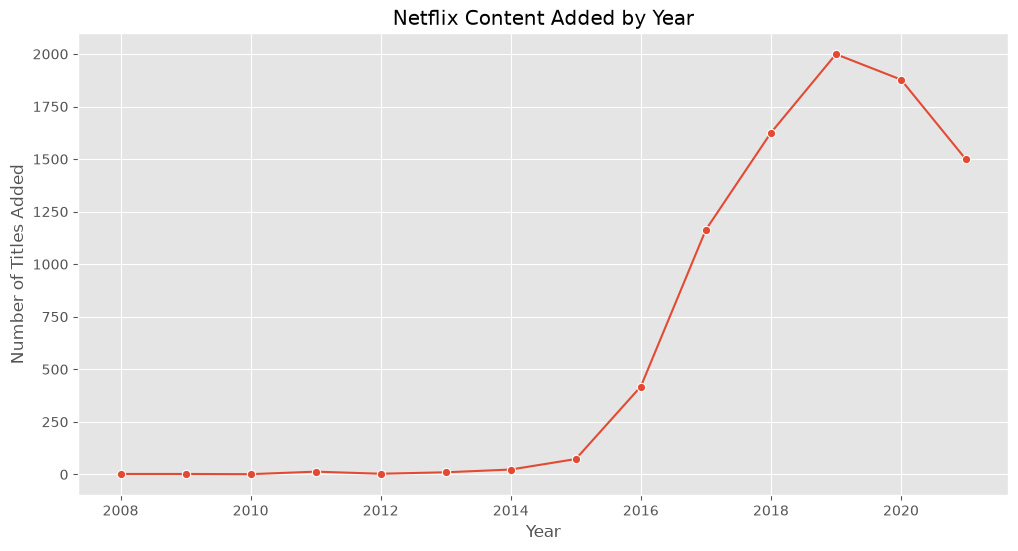

In [12]:
# Convert date_added column to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year
added_year = df['date_added'].dt.year.value_counts().sort_index()

plt.figure(figsize=(12,6))

sns.lineplot(x=added_year.index, y=added_year.values, marker='o')

plt.title("Netflix Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.show()

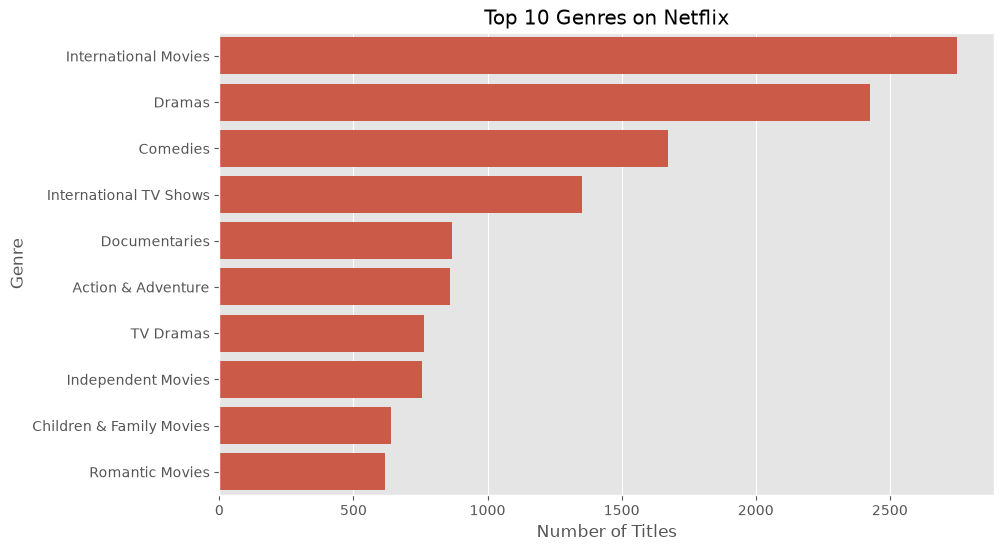

In [13]:
# Top 10 Genres
top_genres = (
    df['listed_in']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(x=top_genres.values, y=top_genres.index)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

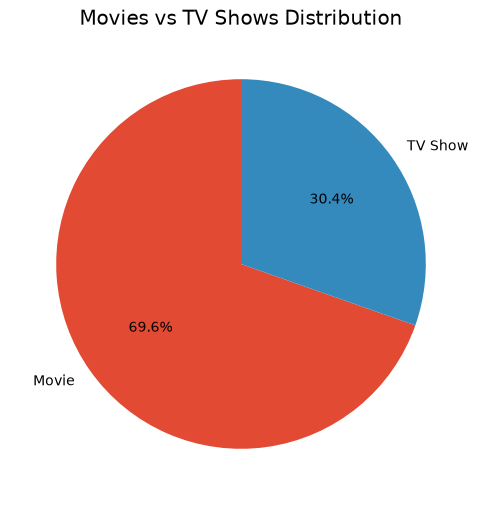

In [14]:
# Movies vs TV Shows Pie Chart
type_counts = df['type'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Movies vs TV Shows Distribution")

plt.show()

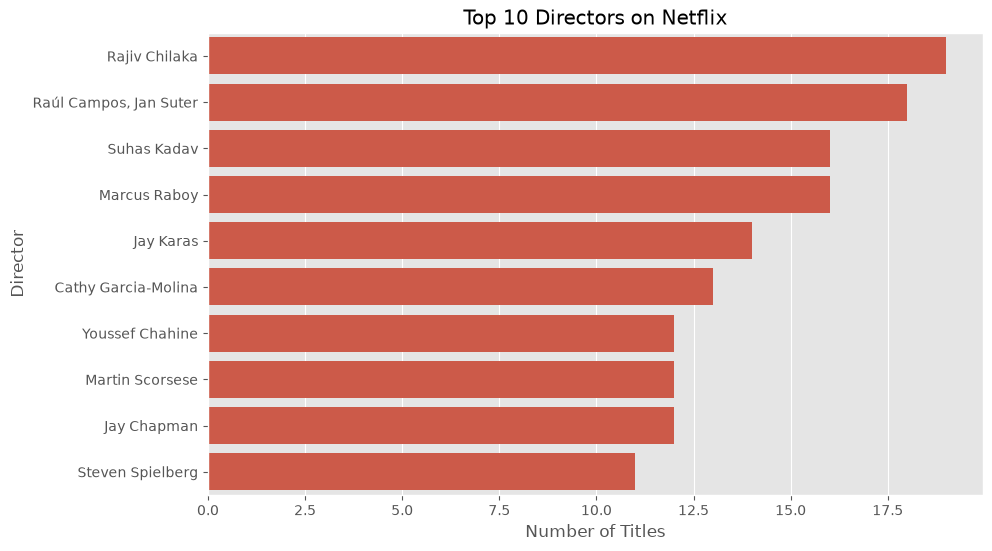

In [15]:
# Top 10 Directors
top_directors = (
    df['director']
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(x=top_directors.values, y=top_directors.index)

plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()

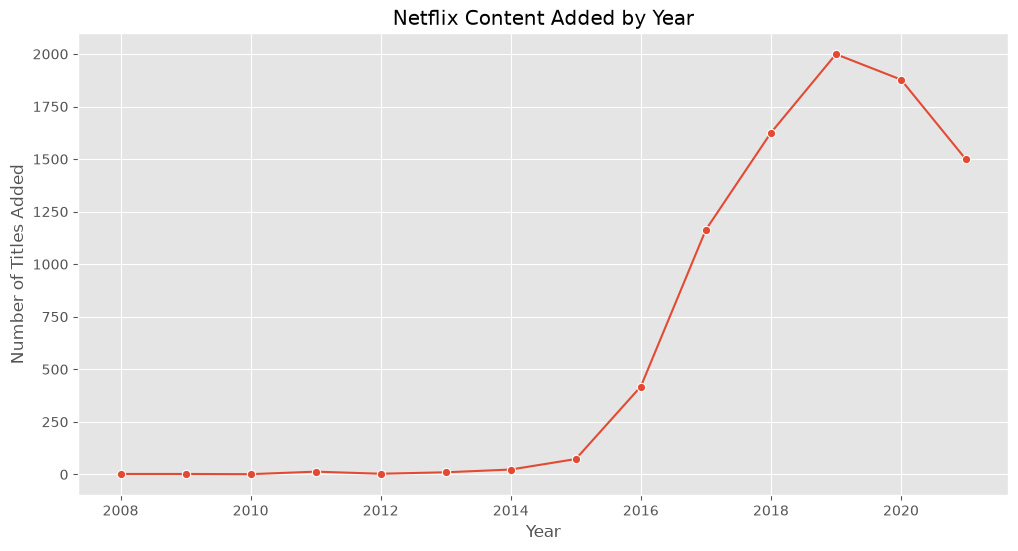

In [16]:
# Convert date_added column to datetime
df['date_added'] = pd.to_datetime(df['date_added'])

added_year = df['date_added'].dt.year.value_counts().sort_index()

plt.figure(figsize=(12,6))

sns.lineplot(x=added_year.index, y=added_year.values, marker='o')

plt.title("Netflix Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.show()

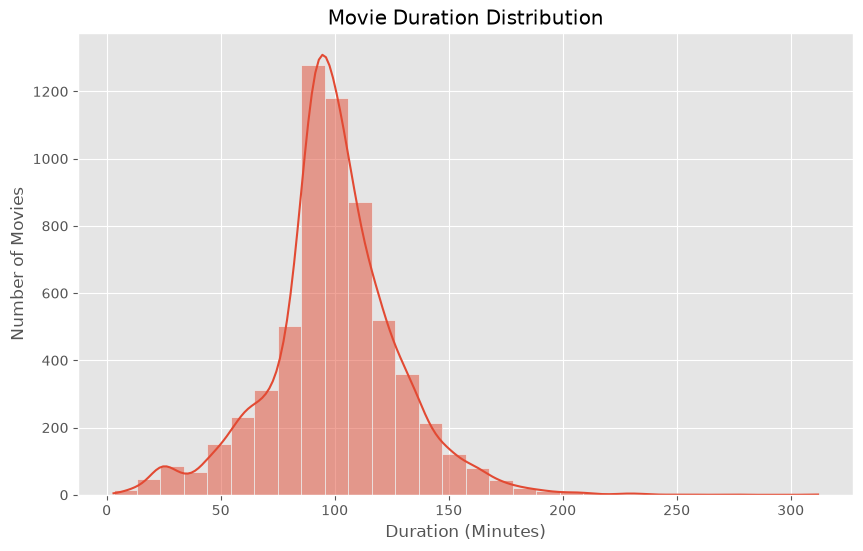

In [17]:
# Movie Duration Distribution
movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.replace(' min', '').astype(float)

plt.figure(figsize=(10,6))

sns.histplot(movies['duration'], bins=30, kde=True)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

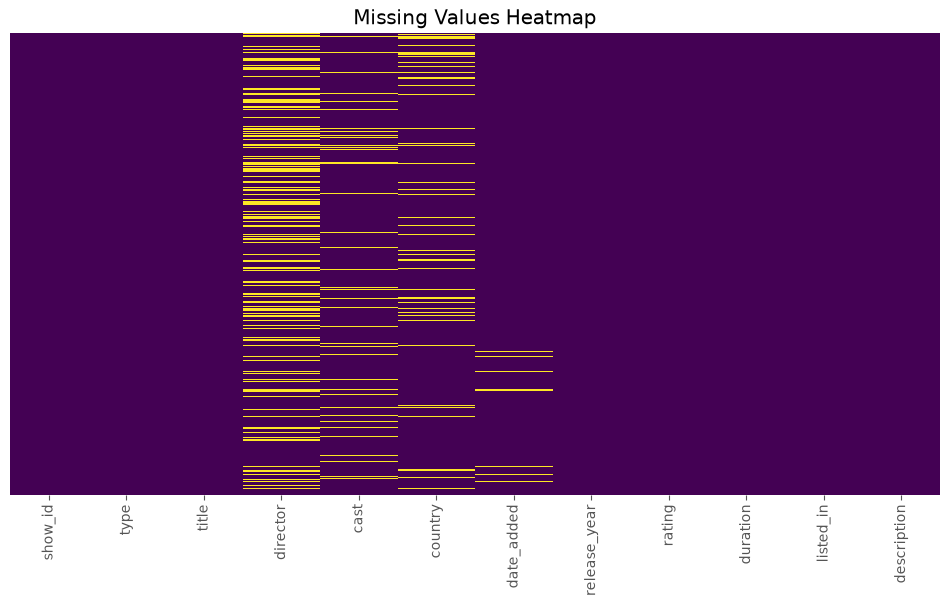

In [18]:
# Missing Values Heatmap
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')

plt.title("Missing Values Heatmap")

plt.show()